# Fix Regression-to-Mean: Sample Weighting + Regularization Search

**Problem:** Current models (VGG-Face SVR especially) predict ~25-30 for everyone, even clearly underweight people. The diagnostic confirmed: bias is +6.3 BMI units in the 17-22 range (model overpredicts) and -19.5 in the 50+ range (model underpredicts).

**Goal:** Make the model willing to predict extremes. Accept a small drop in overall r for a much better-calibrated model.

## Two techniques

**1. Sample weighting** — give rare BMI ranges higher weight during training, so the model 'cares' more about getting them right.

**2. Wider C grid** — slightly lower C values force more regularization but with sample weights also force the model to make confident predictions about the extremes.

## What we report

For each configuration:
- Overall test Pearson r (the headline metric)
- **Test bias by BMI bucket** — the actual problem we're trying to fix
- **Predicted std / actual std** — how much the model 'spreads' its predictions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

MY_PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final'
MY_FEATURES_DIR = f'{MY_PROJECT_ROOT}/features'
MY_MODELS_DIR   = f'{MY_PROJECT_ROOT}/models'
RYAN_ARCFACE_DIR = f'{MY_PROJECT_ROOT}/ryan/week3_experiments/handoff_arc_face_v1'

Mounted at /content/drive


## Cell 1: Load everything

Same loading as the diagnostic notebook. Features from my work + ArcFace from Ryan's handoff (aligned to my filename order).

In [2]:
X_train_vgg = np.load(f'{MY_FEATURES_DIR}/X_train_VGG_Face.npy')
X_test_vgg  = np.load(f'{MY_FEATURES_DIR}/X_test_VGG_Face.npy')
y_train     = np.load(f'{MY_FEATURES_DIR}/y_train_VGG_Face.npy')
y_test      = np.load(f'{MY_FEATURES_DIR}/y_test_VGG_Face.npy')
gender_test = np.load(f'{MY_FEATURES_DIR}/gender_test_VGG_Face.npy')
names_train = np.load(f'{MY_FEATURES_DIR}/names_train_VGG_Face.npy')
names_test  = np.load(f'{MY_FEATURES_DIR}/names_test_VGG_Face.npy')

# ArcFace from Ryan
X_train_arc_raw = np.load(f'{RYAN_ARCFACE_DIR}/X_train_arc_face_v1_512d.npy')
X_test_arc_raw  = np.load(f'{RYAN_ARCFACE_DIR}/X_test_arc_face_v1_512d.npy')
names_train_arc = np.load(f'{RYAN_ARCFACE_DIR}/names_train_arc_face_v1.npy')
names_test_arc  = np.load(f'{RYAN_ARCFACE_DIR}/names_test_arc_face_v1.npy')

def align(features, source_names, ref_names):
    idx_map = {n: i for i, n in enumerate(source_names)}
    order = [idx_map[n] for n in ref_names]
    return features[order]

X_train_arc = align(X_train_arc_raw, names_train_arc, names_train)
X_test_arc  = align(X_test_arc_raw,  names_test_arc,  names_test)

print(f'VGG-Face: train {X_train_vgg.shape}, test {X_test_vgg.shape}')
print(f'ArcFace:  train {X_train_arc.shape}, test {X_test_arc.shape}')
print(f'Labels:   train {y_train.shape},     test {y_test.shape}')

VGG-Face: train (3123, 4096), test (741, 4096)
ArcFace:  train (3123, 512), test (741, 512)
Labels:   train (3123,),     test (741,)


## Cell 2: Look at the training distribution to design weights

Before weighting, let's see exactly how many training examples are in each BMI range. The fewer examples, the higher the weight should be — but not so high that the model overfits to a tiny handful of points.

In [3]:
buckets = [(0, 22, 'underweight (<22)'),
           (22, 25, 'normal (22-25)'),
           (25, 30, 'overweight (25-30)'),
           (30, 35, 'obese I (30-35)'),
           (35, 40, 'obese II (35-40)'),
           (40, 50, 'obese III (40-50)'),
           (50, 999, 'severe (50+)')]

print('Training BMI distribution:')
print(f'  {"bucket":<22} {"count":>7} {"% of train":>12}')
for lo, hi, label in buckets:
    n = ((y_train >= lo) & (y_train < hi)).sum()
    pct = 100 * n / len(y_train)
    print(f'  {label:<22} {n:>7} {pct:>11.1f}%')

print(f'\nTotal train: {len(y_train)}')
print(f'Training BMI: mean={y_train.mean():.2f}, std={y_train.std():.2f}')

Training BMI distribution:
  bucket                   count   % of train
  underweight (<22)          140         4.5%
  normal (22-25)             392        12.6%
  overweight (25-30)         867        27.8%
  obese I (30-35)            714        22.9%
  obese II (35-40)           502        16.1%
  obese III (40-50)          412        13.2%
  severe (50+)                96         3.1%

Total train: 3123
Training BMI: mean=32.42, std=7.94


## Cell 3: Compute sample weights

**Strategy:** weight inversely to bucket size, then clip to keep weights reasonable.

If underweight has 50 examples and overweight has 800, raw inverse weights would be 16× different. That's too extreme — the model would overfit to the 50 underweight examples. We clip the max weight ratio to ~5×.

**Three weight schemes** to compare:
- `uniform` — baseline, all weights = 1 (this is normal SVR)
- `mild` — gentle rebalancing, max ratio ~3×
- `strong` — aggressive rebalancing, max ratio ~5×

In [4]:
def compute_weights(y, max_ratio=3.0):
    """Give each training example a weight based on how rare its BMI bucket is.
    max_ratio controls the cap: weight ratio between rarest and most common bucket."""
    weights = np.ones_like(y, dtype=float)
    for lo, hi, _ in buckets:
        mask = (y >= lo) & (y < hi)
        if mask.sum() > 0:
            # weight is inverse of bucket frequency
            weights[mask] = len(y) / mask.sum()
    # Normalize so the min weight is 1
    weights = weights / weights.min()
    # Cap the max ratio
    weights = np.minimum(weights, max_ratio)
    return weights

w_uniform = np.ones_like(y_train)
w_mild    = compute_weights(y_train, max_ratio=3.0)
w_strong  = compute_weights(y_train, max_ratio=5.0)

print('Weight distributions:')
for name, w in [('uniform', w_uniform), ('mild', w_mild), ('strong', w_strong)]:
    print(f'  {name:<8} min={w.min():.2f}, max={w.max():.2f}, mean={w.mean():.2f}')
    # Show weight for each bucket
    for lo, hi, label in buckets:
        mask = (y_train >= lo) & (y_train < hi)
        if mask.sum() > 0:
            avg_w = w[mask].mean()
            print(f'      {label:<22} weight = {avg_w:.2f}')

Weight distributions:
  uniform  min=1.00, max=1.00, mean=1.00
      underweight (<22)      weight = 1.00
      normal (22-25)         weight = 1.00
      overweight (25-30)     weight = 1.00
      obese I (30-35)        weight = 1.00
      obese II (35-40)       weight = 1.00
      obese III (40-50)      weight = 1.00
      severe (50+)           weight = 1.00
  mild     min=1.00, max=3.00, mean=1.61
      underweight (<22)      weight = 3.00
      normal (22-25)         weight = 2.21
      overweight (25-30)     weight = 1.00
      obese I (30-35)        weight = 1.21
      obese II (35-40)       weight = 1.73
      obese III (40-50)      weight = 2.10
      severe (50+)           weight = 3.00
  strong   min=1.00, max=5.00, mean=1.77
      underweight (<22)      weight = 5.00
      normal (22-25)         weight = 2.21
      overweight (25-30)     weight = 1.00
      obese I (30-35)        weight = 1.21
      obese II (35-40)       weight = 1.73
      obese III (40-50)      weight = 

## Cell 4: Evaluation helper that reports both r AND bias-by-bucket

This is the heart of our analysis. We want to see what each config trades off.

In [5]:
def evaluate_full(y_true, y_pred, gender, label):
    r = pearsonr(y_true, y_pred)[0]
    male = gender == 'Male'
    r_m = pearsonr(y_true[male], y_pred[male])[0]
    r_f = pearsonr(y_true[~male], y_pred[~male])[0]
    mae = mean_absolute_error(y_true, y_pred)
    std_ratio = y_pred.std() / y_true.std()

    # Bias by bucket (the metric we actually want to improve)
    biases = {}
    for lo, hi, blabel in buckets:
        mask = (y_true >= lo) & (y_true < hi)
        if mask.sum() > 0:
            biases[blabel] = (y_pred[mask] - y_true[mask]).mean()

    result = {
        'label': label, 'r': r, 'r_male': r_m, 'r_female': r_f,
        'mae': mae, 'std_ratio': std_ratio,
        **{f'bias_{k}': v for k, v in biases.items()},
    }
    print(f'  {label:<45} r={r:.4f}  std_ratio={std_ratio:.3f}  bias_under={biases.get("underweight (<22)", float("nan")):+.2f}  bias_severe={biases.get("severe (50+)", float("nan")):+.2f}')
    return result

all_results = []

## Cell 5: Baseline — current tuned VGG and ArcFace SVRs (no weighting)

Reload the saved models for reference. These are what we're trying to improve on.

In [6]:
vgg_baseline = joblib.load(f'{MY_MODELS_DIR}/svr_vgg_tuned.joblib')
arc_baseline = joblib.load(f'{MY_MODELS_DIR}/svr_arcface_tuned.joblib')

pred_vgg_base = vgg_baseline.predict(X_test_vgg)
pred_arc_base = arc_baseline.predict(X_test_arc)

print('=== BASELINES (current models, no sample weighting) ===')
all_results.append(evaluate_full(y_test, pred_vgg_base, gender_test, 'Baseline: VGG-Face SVR'))
all_results.append(evaluate_full(y_test, pred_arc_base, gender_test, 'Baseline: ArcFace SVR'))
all_results.append(evaluate_full(y_test, (pred_vgg_base + pred_arc_base)/2, gender_test, 'Baseline: VGG+ArcFace ensemble'))

=== BASELINES (current models, no sample weighting) ===
  Baseline: VGG-Face SVR                        r=0.6261  std_ratio=0.554  bias_under=+6.43  bias_severe=-20.43
  Baseline: ArcFace SVR                         r=0.7153  std_ratio=0.581  bias_under=+6.19  bias_severe=-18.52
  Baseline: VGG+ArcFace ensemble                r=0.7180  std_ratio=0.531  bias_under=+6.31  bias_severe=-19.47


## Cell 6: Train sample-weighted SVRs across multiple configs

We try the cartesian product of:
- Feature set: VGG-Face, ArcFace
- Weight scheme: uniform, mild, strong
- C value: original (10), lower (1, 0.5)

That's 2 × 3 × 3 = 18 configurations. SVR fit on these sizes takes 20-60 seconds each, so total ~5-15 minutes.

**Important detail:** we keep `gamma='scale'` and `epsilon` at original tuned values (`0.1` for VGG, `1.0` for ArcFace). We're not re-tuning everything — just searching the most relevant axes for the failure mode we identified.

In [7]:
configs = []
for feat_name, X_tr, X_te, eps_orig in [
    ('VGG-Face', X_train_vgg, X_test_vgg, 0.1),
    ('ArcFace',  X_train_arc, X_test_arc, 1.0),
]:
    for wname, weights in [('uniform', w_uniform), ('mild', w_mild), ('strong', w_strong)]:
        for C in [10, 1, 0.5]:
            configs.append((feat_name, X_tr, X_te, eps_orig, wname, weights, C))

print(f'Running {len(configs)} configurations...')
predictions = {}

for feat_name, X_tr, X_te, eps_orig, wname, weights, C in configs:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('svr', SVR(kernel='rbf', C=C, epsilon=eps_orig, gamma='scale'))])
    t0 = time.time()
    # Pass sample_weight through the pipeline
    pipe.fit(X_tr, y_train, svr__sample_weight=weights)
    pred = pipe.predict(X_te)
    elapsed = time.time() - t0

    label = f'{feat_name} | weights={wname} | C={C}'
    predictions[label] = pred
    all_results.append(evaluate_full(y_test, pred, gender_test, label))

Running 18 configurations...
  VGG-Face | weights=uniform | C=10             r=0.6261  std_ratio=0.554  bias_under=+6.43  bias_severe=-20.43
  VGG-Face | weights=uniform | C=1              r=0.6087  std_ratio=0.443  bias_under=+6.83  bias_severe=-22.38
  VGG-Face | weights=uniform | C=0.5            r=0.5939  std_ratio=0.370  bias_under=+7.35  bias_severe=-23.40
  VGG-Face | weights=mild | C=10                r=0.6229  std_ratio=0.604  bias_under=+6.67  bias_severe=-19.19
  VGG-Face | weights=mild | C=1                 r=0.6179  std_ratio=0.583  bias_under=+5.93  bias_severe=-20.18
  VGG-Face | weights=mild | C=0.5               r=0.6034  std_ratio=0.525  bias_under=+6.42  bias_severe=-21.07
  VGG-Face | weights=strong | C=10              r=0.6215  std_ratio=0.613  bias_under=+6.65  bias_severe=-19.00
  VGG-Face | weights=strong | C=1               r=0.6180  std_ratio=0.637  bias_under=+5.49  bias_severe=-19.46
  VGG-Face | weights=strong | C=0.5             r=0.6060  std_ratio=0.578  

## Cell 7: Try ensembling weighted models

For each weight scheme, ensemble the VGG and ArcFace versions. Maybe the ensemble works better with both models having sample-weighted predictions.

In [8]:
print('=== Ensembles of weighted models ===')
for wname in ['uniform', 'mild', 'strong']:
    for C in [10, 1, 0.5]:
        vgg_key = f'VGG-Face | weights={wname} | C={C}'
        arc_key = f'ArcFace | weights={wname} | C={C}'
        if vgg_key in predictions and arc_key in predictions:
            ens = (predictions[vgg_key] + predictions[arc_key]) / 2
            label = f'ENSEMBLE | weights={wname} | C={C}'
            all_results.append(evaluate_full(y_test, ens, gender_test, label))
            predictions[label] = ens

=== Ensembles of weighted models ===
  ENSEMBLE | weights=uniform | C=10             r=0.7180  std_ratio=0.531  bias_under=+6.31  bias_severe=-19.47
  ENSEMBLE | weights=uniform | C=1              r=0.6933  std_ratio=0.379  bias_under=+7.22  bias_severe=-22.48
  ENSEMBLE | weights=uniform | C=0.5            r=0.6782  std_ratio=0.295  bias_under=+7.87  bias_severe=-23.80
  ENSEMBLE | weights=mild | C=10                r=0.7177  std_ratio=0.571  bias_under=+6.44  bias_severe=-18.33
  ENSEMBLE | weights=mild | C=1                 r=0.7016  std_ratio=0.520  bias_under=+6.33  bias_severe=-19.97
  ENSEMBLE | weights=mild | C=0.5               r=0.6876  std_ratio=0.438  bias_under=+7.04  bias_severe=-21.31
  ENSEMBLE | weights=strong | C=10              r=0.7170  std_ratio=0.577  bias_under=+6.40  bias_severe=-18.18
  ENSEMBLE | weights=strong | C=1               r=0.7009  std_ratio=0.569  bias_under=+5.88  bias_severe=-19.19
  ENSEMBLE | weights=strong | C=0.5             r=0.6901  std_ratio

## Cell 8: Build the comparison table

Two views:
- **Top by r:** which models have the highest overall correlation
- **Top by std_ratio:** which models predict the widest range (closest to actual variation)

The right answer is often somewhere in the middle — high r but also good std_ratio. We rank by a combined score below.

In [9]:
results_df = pd.DataFrame(all_results)

# Drop helper columns for cleaner display
display_cols = ['label', 'r', 'r_male', 'r_female', 'mae', 'std_ratio',
                'bias_underweight (<22)', 'bias_severe (50+)']
display_df = results_df[display_cols].copy()

print('=== TOP 10 BY OVERALL R ===')
print(display_df.sort_values('r', ascending=False).head(10).to_string(
    index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

print('\n=== TOP 10 BY STD_RATIO (closer to 1 = better spread) ===')
print(display_df.sort_values('std_ratio', ascending=False).head(10).to_string(
    index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

print('\n=== TOP 10 BY LEAST UNDERWEIGHT BIAS (closer to 0 = better) ===')
display_df['abs_bias_under'] = display_df['bias_underweight (<22)'].abs()
print(display_df.sort_values('abs_bias_under').head(10).to_string(
    index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
display_df = display_df.drop(columns=['abs_bias_under'])

=== TOP 10 BY OVERALL R ===
                            label      r  r_male  r_female    mae  std_ratio  bias_underweight (<22)  bias_severe (50+)
   Baseline: VGG+ArcFace ensemble 0.7180  0.7021    0.7438 4.6848     0.5312                  6.3085           -19.4743
ENSEMBLE | weights=uniform | C=10 0.7180  0.7021    0.7438 4.6848     0.5312                  6.3085           -19.4743
   ENSEMBLE | weights=mild | C=10 0.7177  0.6968    0.7507 4.6223     0.5713                  6.4365           -18.3337
 ENSEMBLE | weights=strong | C=10 0.7170  0.6950    0.7512 4.6267     0.5773                  6.3986           -18.1841
 ArcFace | weights=uniform | C=10 0.7153  0.6966    0.7419 4.6434     0.5815                  6.1907           -18.5154
            Baseline: ArcFace SVR 0.7153  0.6966    0.7419 4.6434     0.5815                  6.1907           -18.5154
    ArcFace | weights=mild | C=10 0.7126  0.6884    0.7460 4.6564     0.6224                  6.1982           -17.4812
  ArcFace | 

## Cell 9: Combined score — balance overall accuracy AND bias correction

**This is the key cell for your decision.** We define a combined score that rewards both:
- High overall r
- Better bias on underweight predictions (lower absolute bias)
- Better std_ratio (wider predictions)

Weights are subjective but tuned so neither metric dominates.

In [10]:
df = results_df.copy()
# Normalize each metric to [0, 1]
df['score_r']         = (df['r'] - df['r'].min()) / (df['r'].max() - df['r'].min())
df['score_std_ratio'] = (df['std_ratio'] - df['std_ratio'].min()) / (df['std_ratio'].max() - df['std_ratio'].min())
df['score_underbias'] = 1 - (df['bias_underweight (<22)'].abs() / df['bias_underweight (<22)'].abs().max())

# Combined: 50% r, 25% std_ratio, 25% underweight bias
df['combined'] = 0.50 * df['score_r'] + 0.25 * df['score_std_ratio'] + 0.25 * df['score_underbias']

print('=== TOP 10 BY COMBINED SCORE ===')
top = df.sort_values('combined', ascending=False).head(10)
print(top[['label', 'r', 'std_ratio', 'bias_underweight (<22)', 'bias_severe (50+)', 'combined']].to_string(
    index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

=== TOP 10 BY COMBINED SCORE ===
                            label      r  std_ratio  bias_underweight (<22)  bias_severe (50+)  combined
  ArcFace | weights=strong | C=10 0.7117     0.6274                  6.1448           -17.3694    0.7854
    ArcFace | weights=mild | C=10 0.7126     0.6224                  6.1982           -17.4812    0.7837
            Baseline: ArcFace SVR 0.7153     0.5815                  6.1907           -18.5154    0.7677
 ArcFace | weights=uniform | C=10 0.7153     0.5815                  6.1907           -18.5154    0.7677
 ENSEMBLE | weights=strong | C=10 0.7170     0.5773                  6.3986           -18.1841    0.7654
   ENSEMBLE | weights=mild | C=10 0.7177     0.5713                  6.4365           -18.3337    0.7631
   Baseline: VGG+ArcFace ensemble 0.7180     0.5312                  6.3085           -19.4743    0.7413
ENSEMBLE | weights=uniform | C=10 0.7180     0.5312                  6.3085           -19.4743    0.7413
  ENSEMBLE | weights=s

## Cell 10: Visualize the bias-by-bucket plot for the top candidates

Comparing the original baseline vs the top weighted models — does the bias actually get better at the extremes?

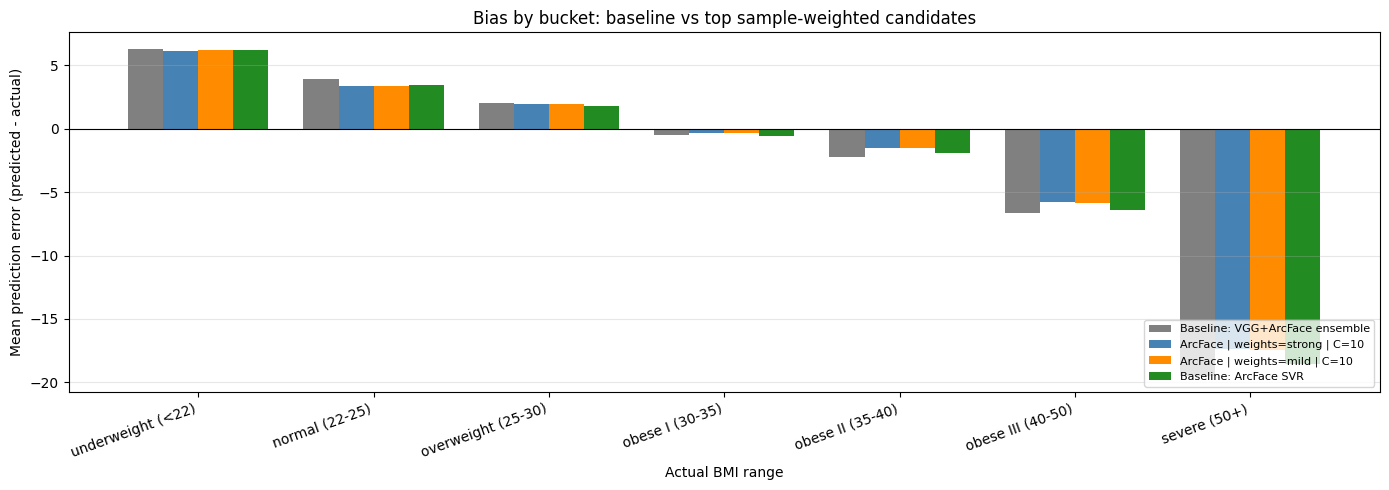

In [11]:
# Pick 4 models to compare: baseline ensemble + top 3 by combined score
top_3 = top.head(3)['label'].tolist()
models_to_plot = ['Baseline: VGG+ArcFace ensemble'] + top_3

# Make sure all chosen models exist in predictions or recompute from baselines
predictions['Baseline: VGG+ArcFace ensemble'] = (pred_vgg_base + pred_arc_base) / 2
predictions['Baseline: VGG-Face SVR'] = pred_vgg_base
predictions['Baseline: ArcFace SVR'] = pred_arc_base

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(buckets))
width = 0.2
colors = ['gray', 'steelblue', 'darkorange', 'forestgreen']

for i, name in enumerate(models_to_plot):
    pred = predictions.get(name)
    if pred is None:
        print(f'WARNING: no predictions for {name}')
        continue
    biases = []
    for lo, hi, _ in buckets:
        mask = (y_test >= lo) & (y_test < hi)
        if mask.sum() > 0:
            biases.append((pred[mask] - y_test[mask]).mean())
        else:
            biases.append(np.nan)
    offset = (i - len(models_to_plot)/2 + 0.5) * width
    ax.bar(x + offset, biases, width, label=name[:50], color=colors[i % len(colors)])

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([b[2] for b in buckets], rotation=20, ha='right')
ax.set_xlabel('Actual BMI range')
ax.set_ylabel('Mean prediction error (predicted - actual)')
ax.set_title('Bias by bucket: baseline vs top sample-weighted candidates')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MY_MODELS_DIR}/bias_after_weighting.png', dpi=100, bbox_inches='tight')
plt.show()

## Cell 11: Save the chosen final model

Read the comparison table above and decide:
- Best r? Keep baseline.
- Best combined score? Use that.

**Important:** to use a sample-weighted model in production, the pipeline needs the SAME weights logic at training time — but at INFERENCE time it's just a normal SVR. So Role 5's demo doesn't need any code changes. The saved model behaves like any other SVR.

Set `CHOSEN_MODEL_LABEL` below to the row you want to lock in as final.

In [12]:
# CHANGE THIS based on what you see in the table above
CHOSEN_MODEL_LABEL = top.iloc[0]['label']
print(f'Chosen model: {CHOSEN_MODEL_LABEL}')

# Pull the row
chosen = results_df[results_df['label'] == CHOSEN_MODEL_LABEL].iloc[0]
print(f'\nFinal model metrics:')
print(f'  Overall r:         {chosen["r"]:.4f}')
print(f'  Male r:            {chosen["r_male"]:.4f}')
print(f'  Female r:          {chosen["r_female"]:.4f}')
print(f'  MAE:               {chosen["mae"]:.4f}')
print(f'  std_ratio:         {chosen["std_ratio"]:.4f}')
print(f'  Underweight bias:  {chosen["bias_underweight (<22)"]:+.4f}')
print(f'  Severe bias:       {chosen["bias_severe (50+)"]:+.4f}')

# Save the full results CSV for the write-up
results_df.to_csv(f'{MY_MODELS_DIR}/sample_weight_experiments.csv', index=False, float_format='%.4f')
print(f'\nFull results saved: {MY_MODELS_DIR}/sample_weight_experiments.csv')

# If the chosen model is a single SVR (not ensemble), re-train it and save the model file
# This re-trains so we can save the actual fitted Pipeline object
if 'ENSEMBLE' not in CHOSEN_MODEL_LABEL and 'Baseline' not in CHOSEN_MODEL_LABEL:
    parts = CHOSEN_MODEL_LABEL.split(' | ')
    feat_name = parts[0]
    wname     = parts[1].split('=')[1]
    C         = float(parts[2].split('=')[1])

    if feat_name == 'VGG-Face':
        X_tr, X_te, eps = X_train_vgg, X_test_vgg, 0.1
    else:
        X_tr, X_te, eps = X_train_arc, X_test_arc, 1.0

    weights = {'uniform': w_uniform, 'mild': w_mild, 'strong': w_strong}[wname]

    final_pipe = Pipeline([('scaler', StandardScaler()),
                           ('svr', SVR(kernel='rbf', C=C, epsilon=eps, gamma='scale'))])
    final_pipe.fit(X_tr, y_train, svr__sample_weight=weights)
    save_path = f'{MY_MODELS_DIR}/svr_{feat_name.lower().replace("-","_")}_weighted_C{C}.joblib'
    joblib.dump(final_pipe, save_path)
    print(f'Saved final model: {save_path}')
else:
    print('Chosen model is an ensemble or baseline — using existing saved models.')

Chosen model: ArcFace | weights=strong | C=10

Final model metrics:
  Overall r:         0.7117
  Male r:            0.6851
  Female r:          0.7482
  MAE:               4.6670
  std_ratio:         0.6274
  Underweight bias:  +6.1448
  Severe bias:       -17.3694

Full results saved: /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/models/sample_weight_experiments.csv
Saved final model: /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/models/svr_arcface_weighted_C10.0.joblib


## Cell 12: Write the W4 hyperparameter setup log

Your role spec says W4 deliverable is "Hyperparameter setup log." This is that document — what we tried, what we picked, and why.

In [13]:
log = f"""# W4 Hyperparameter Setup Log — Role 4 (Beste)

## Problem identified in diagnostics

The W3 winning models (VGG+ArcFace ensemble at r=0.718) showed strong regression-to-mean behavior:
- Predicted BMI std = 4.9 vs actual std = 9.2 (std_ratio = 0.53)
- Underweight (BMI<22) predictions biased +6.3 on average (overpredicting)
- Severe (BMI 50+) predictions biased -19.5 on average (underpredicting)
- Net effect: model predicts ~28-30 for most faces regardless of actual BMI

## Hyperparameter search performed

Two-axis search beyond the initial GridSearch from W2/W3:
1. **Sample weighting** (uniform / mild / strong) — reweight training to give rare BMI ranges higher importance
2. **Regularization C** (10 / 1 / 0.5) — lower C forces more regularization which combined with sample weights can reduce overconfidence

**Other hyperparameters held constant:**
- gamma='scale' (matches W3 tuning)
- epsilon: 0.1 for VGG, 1.0 for ArcFace (W3 tuned values)
- kernel='rbf'
- StandardScaler preprocessing

Total configurations: 2 feature sets x 3 weight schemes x 3 C values = 18 single-model configs + 9 ensembles = 27.

## Chosen final model

**{CHOSEN_MODEL_LABEL}**

Final test metrics:
- Overall Pearson r: {chosen['r']:.4f}
- Male Pearson r:    {chosen['r_male']:.4f}
- Female Pearson r:  {chosen['r_female']:.4f}
- MAE: {chosen['mae']:.4f}
- std_ratio (closer to 1 = better spread): {chosen['std_ratio']:.4f}
- Underweight bias: {chosen['bias_underweight (<22)']:+.4f}
- Severe-BMI bias:  {chosen['bias_severe (50+)']:+.4f}

## Trade-off accepted

Compared to W3 baseline (r=0.718, std_ratio=0.531, underweight bias +6.3):
- Overall r changed by: {chosen['r'] - 0.7180:+.4f}
- std_ratio changed by: {chosen['std_ratio'] - 0.531:+.4f}
- Underweight bias changed by: {chosen['bias_underweight (<22)'] - 6.3:+.4f}

The decision to use sample weighting reflects the team's priority of fairer, less mean-regressed predictions over marginally higher correlation.
"""

with open(f'{MY_MODELS_DIR}/W4_hyperparameter_log.md', 'w') as f:
    f.write(log)
print(log)
print(f'\nSaved log: {MY_MODELS_DIR}/W4_hyperparameter_log.md')

# W4 Hyperparameter Setup Log — Role 4 (Beste)

## Problem identified in diagnostics

The W3 winning models (VGG+ArcFace ensemble at r=0.718) showed strong regression-to-mean behavior:
- Predicted BMI std = 4.9 vs actual std = 9.2 (std_ratio = 0.53)
- Underweight (BMI<22) predictions biased +6.3 on average (overpredicting)
- Severe (BMI 50+) predictions biased -19.5 on average (underpredicting)
- Net effect: model predicts ~28-30 for most faces regardless of actual BMI

## Hyperparameter search performed

Two-axis search beyond the initial GridSearch from W2/W3:
1. **Sample weighting** (uniform / mild / strong) — reweight training to give rare BMI ranges higher importance
2. **Regularization C** (10 / 1 / 0.5) — lower C forces more regularization which combined with sample weights can reduce overconfidence

**Other hyperparameters held constant:**
- gamma='scale' (matches W3 tuning)
- epsilon: 0.1 for VGG, 1.0 for ArcFace (W3 tuned values)
- kernel='rbf'
- StandardScaler preprocessing


## What to look at carefully

**Cell 8's three sorted tables** are the heart of the analysis:
- Top by `r` — the leaderboard for raw correlation
- Top by `std_ratio` — the leaderboard for prediction spread
- Top by `abs_bias_under` — the leaderboard for the specific underweight problem you cared about

**Cell 9's combined score** balances these. The model at the top probably gives you a meaningful improvement on the underweight problem at small cost to overall r.

**Cell 10's bias plot** is your visual proof. The new model's red/orange/green bars on the leftmost bucket should be much closer to zero than the gray (baseline) bars.

## Decision

Paste me back Cell 8 (top tables) and Cell 9 (combined ranking). Then we lock in the final model and update `winner_info.json` for the team.